### 1. Configuración y Carga de Datos

In [122]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
from typing import Any

In [123]:
# Configuración inicial para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

In [124]:
# --- Cargar los datos ---
# Reemplaza con la ruta real de tu archivo
file_path = "fires-all.csv"

In [125]:
try:
    # Cargar con polars, infiriendo el esquema automáticamente
    df = pl.read_csv(file_path, try_parse_dates=True)
    print(f'Dataset cargado correctamente. Dimensiones: {df.shape}')
except Exception as e:
    print(f'Error al cargar el archivo: {e}')

Dataset cargado correctamente. Dimensiones: (292181, 21)


### 2. Visión General y Limpieza Inicial
##### 2.1. Estructura y Tipos de Datos

In [126]:
# Mostrar las primeras filas y el esquema
print("----- Primeras 5 filas -----")
print(df.head())

print("\n----- Esquema del DataFrame -----")
print(df.schema)

----- Primeras 5 filas -----
shape: (5, 21)
┌────────────┬────────────┬────────────┬──────┬───┬──────────┬────────┬────────┬──────────┐
│ id         ┆ superficie ┆ fecha      ┆ lat  ┆ … ┆ personal ┆ medios ┆ gastos ┆ perdidas │
│ ---        ┆ ---        ┆ ---        ┆ ---  ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---      │
│ i64        ┆ f64        ┆ date       ┆ str  ┆   ┆ i64      ┆ i64    ┆ i64    ┆ i64      │
╞════════════╪════════════╪════════════╪══════╪═══╪══════════╪════════╪════════╪══════════╡
│ 1968290001 ┆ 14.0       ┆ 1968-01-01 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968430003 ┆ 3.0        ┆ 1968-01-03 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968290006 ┆ 2.0        ┆ 1968-01-06 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968120007 ┆ 8.2        ┆ 1968-01-07 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968430016 ┆ 600.0      ┆ 1968-01-07 ┆ null ┆ … ┆ 35       ┆ 1      ┆ 0      ┆ 0        │
└────────────┴────────────┴─────────

In [127]:
# Resumen estadístico de columnas numéricas
print("\n----- Resumen Estadístico (Numéricas) -----")
print(df.describe())


----- Resumen Estadístico (Numéricas) -----
shape: (9, 22)
┌────────────┬──────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ statistic  ┆ id       ┆ superfici ┆ fecha     ┆ … ┆ personal  ┆ medios   ┆ gastos    ┆ perdidas  │
│ ---        ┆ ---      ┆ e         ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ str        ┆ f64      ┆ ---       ┆ str       ┆   ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
│            ┆          ┆ f64       ┆           ┆   ┆           ┆          ┆           ┆           │
╞════════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ count      ┆ 292181.0 ┆ 292181.0  ┆ 292181    ┆ … ┆ 292181.0  ┆ 292181.0 ┆ 292181.0  ┆ 292181.0  │
│ null_count ┆ 0.0      ┆ 0.0       ┆ 0         ┆ … ┆ 0.0       ┆ 0.0      ┆ 0.0       ┆ 0.0       │
│ mean       ┆ 1.9952e9 ┆ 26.751764 ┆ 1995-05-2 ┆ … ┆ 22.088757 ┆ 2.065531 ┆ 593.28045 ┆ 8461.0676 │
│            ┆          ┆      

> <br/>
> 💡 Observaciones Iniciales:
>
> - Rango temporal: 1968-2023.
> - Columnas Clave: superficie, fecha, lat, lng, gastos, perdidas, etc.
> - Datos Faltantes: Según la documentación, campos como gastos y perdidas tienen muchos valores nulos. time_ctrl, time_ext, personal, medios también pueden tenerlos.
>
> <br/>


##### 2.2. Limpieza de Datos y Manejo de Nulos

In [128]:
# Calcular porcentaje de nulos por columna
null_percent = df.select([
    pl.col(col).is_null().mean().round(4) * 100 for col in df.columns
])
print("----- Porcentaje de Nulos por Columna -----")
print(null_percent)

----- Porcentaje de Nulos por Columna -----
shape: (1, 21)
┌─────┬────────────┬───────┬───────┬───┬──────────┬────────┬────────┬──────────┐
│ id  ┆ superficie ┆ fecha ┆ lat   ┆ … ┆ personal ┆ medios ┆ gastos ┆ perdidas │
│ --- ┆ ---        ┆ ---   ┆ ---   ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---      │
│ f64 ┆ f64        ┆ f64   ┆ f64   ┆   ┆ f64      ┆ f64    ┆ f64    ┆ f64      │
╞═════╪════════════╪═══════╪═══════╪═══╪══════════╪════════╪════════╪══════════╡
│ 0.0 ┆ 0.0        ┆ 0.0   ┆ 18.63 ┆ … ┆ 0.0      ┆ 0.0    ┆ 0.0    ┆ 0.0      │
└─────┴────────────┴───────┴───────┴───┴──────────┴────────┴────────┴──────────┘


In [129]:
# Estrategias de limpieza:
# 1. Fechas: Convertir a datetime (ya está hecho con try_parse_dates)
# 2. Causa_supuesta: Los valores en blanco los convertimos a null o '0' para claridad.
df = df.with_columns(
    pl.col("causa_supuesta").cast(pl.Utf8)  # Aseguramos que sea string
)

In [130]:
# Reemplazar cadenas vacías por None y luego a entero (0) o mantener como categoría
df = df.with_columns(
    pl.when(pl.col("causa_supuesta").str.strip_chars() == "")
    .then(pl.lit(None))
    .otherwise(pl.col("causa_supuesta"))
    .cast(pl.Int8)  # 1 o nulo
    .alias("causa_supuesta")
)

### 3. Análisis Univariante (Distribuciones)
##### 3.1. Variables Numéricas: Superficie, Gastos y Pérdidas

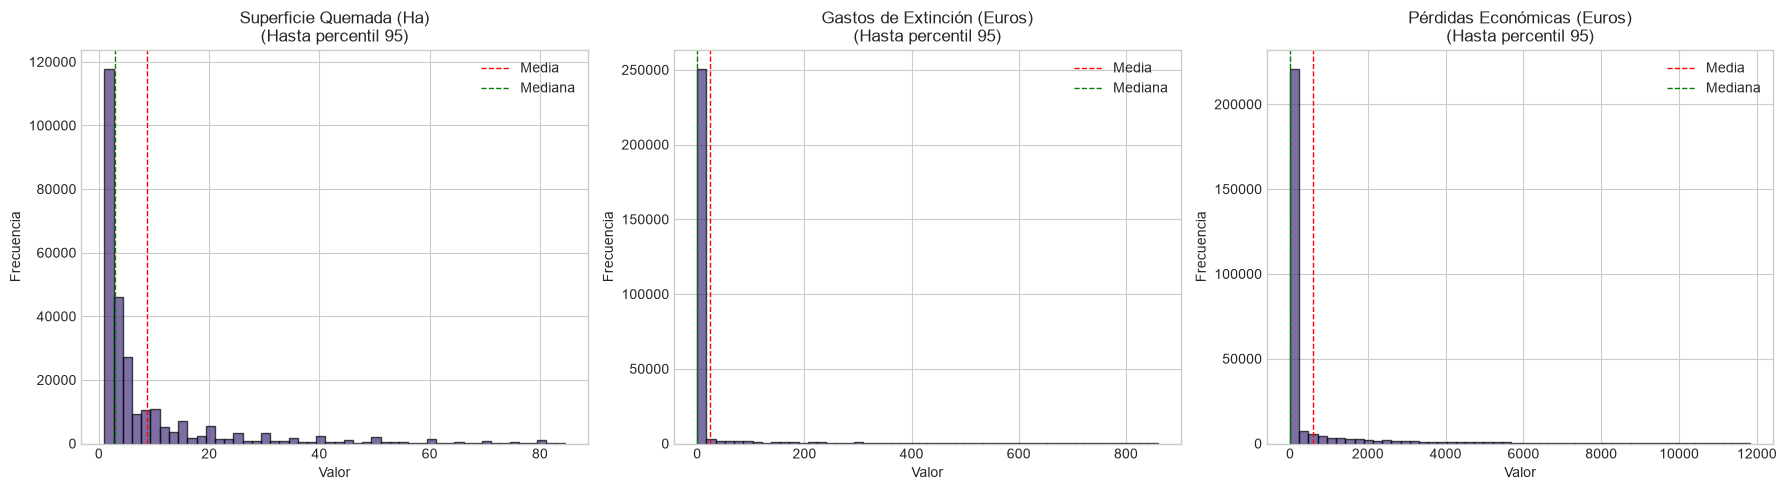

In [131]:
# Histogramas de variables clave (usando datos sin nulos)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variables = ['superficie', 'gastos', 'perdidas']
titles = ['Superficie Quemada (Ha)', 'Gastos de Extinción (Euros)', 'Pérdidas Económicas (Euros)']

for i, var in enumerate(variables):
    # Filtrar valores atípicos extremos para mejor visualización (percentil 95)
    q95 = df[var].quantile(0.95)
    data_plot = df.filter(pl.col(var) <= q95)[var].to_numpy()
    
    axes[i].hist(data_plot, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{titles[i]}\n(Hasta percentil 95)', fontsize=12)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(np.mean(data_plot), color='red', linestyle='dashed', linewidth=1, label='Media')
    axes[i].axvline(np.median(data_plot), color='green', linestyle='dashed', linewidth=1, label='Mediana')
    axes[i].legend()

plt.tight_layout()
plt.show() # type: ignore

> <br/>
>
> 💡 Conclusión: Las distribuciones de `superficie`, `gastos` y `perdidas` están muy sesgadas a la derecha. (cola larga hacia valores altos). La mayoría de los incendios son pequeños, pero unos pocos concentran la mayor parte de la superficie, gastos y pérdidas.
>
> <br/>


##### 3.2. Variables Temporales: Tendencias Anuales

In [132]:
df = df.with_columns(pl.col("fecha").dt.year().alias("anio"))

In [133]:
# Conteo de incendios y superficie total quemada por año
yearly_stats = df.group_by("anio").agg([
    pl.count().alias("num_incendios"),
    pl.sum("superficie").alias("superficie_total"),
    pl.mean("superficie").alias("superficie_promedio")
]).sort("anio")

print("----- Estadísticas Anuales -----")
print(yearly_stats.tail(10))

----- Estadísticas Anuales -----
shape: (10, 4)
┌──────┬───────────────┬──────────────────┬─────────────────────┐
│ anio ┆ num_incendios ┆ superficie_total ┆ superficie_promedio │
│ ---  ┆ ---           ┆ ---              ┆ ---                 │
│ i32  ┆ u32           ┆ f64              ┆ f64                 │
╞══════╪═══════════════╪══════════════════╪═════════════════════╡
│ 2014 ┆ 3196          ┆ 47154.13         ┆ 14.754108           │
│ 2015 ┆ 4125          ┆ 108110.91        ┆ 26.208705           │
│ 2016 ┆ 2432          ┆ 67971.48         ┆ 27.948799           │
│ 2017 ┆ 5223          ┆ 181649.7512      ┆ 34.778815           │
│ 2018 ┆ 2004          ┆ 25900.2557       ┆ 12.924279           │
│ 2019 ┆ 3796          ┆ 84857.8305       ┆ 22.354539           │
│ 2020 ┆ 2287          ┆ 64562.5286       ┆ 28.230227           │
│ 2021 ┆ 888           ┆ 40918.641        ┆ 46.079551           │
│ 2022 ┆ 226           ┆ 12443.34         ┆ 55.059027           │
│ 2023 ┆ 23            ┆ 53.

C:\Users\MFR\AppData\Local\Temp\ipykernel_10888\307796821.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_incendios"),


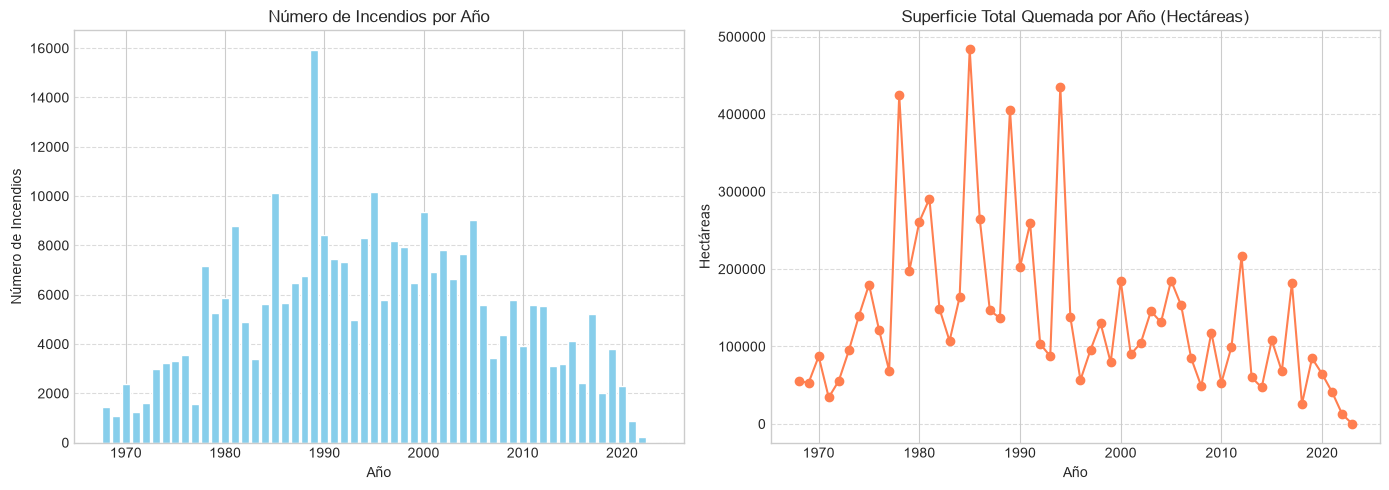

In [134]:
# Gráficos de tendencias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly_stats['anio'], yearly_stats['num_incendios'], color='skyblue')
axes[0].set_title('Número de Incendios por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de Incendios')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].plot(yearly_stats['anio'], yearly_stats['superficie_total'], marker='o', linestyle='-', color='coral')
axes[1].set_title('Superficie Total Quemada por Año (Hectáreas)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Hectáreas')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show() # type: ignore

> <br/>
> 💡 Observación: Se pueden ver años con picos muy altos (ej. 1985, 1994, 2012, 2022) que probablemente coinciden con grandes incendios o sequías. La tendencia a largo plazo podría ser decreciente en número de incendios pero con grandes picos en superficie.

> <br/>


### 4. Análisis Bivariante y Multivariante
##### 4.1. Relación Superficie vs. Recursos (Personal, Medios, Tiempos)

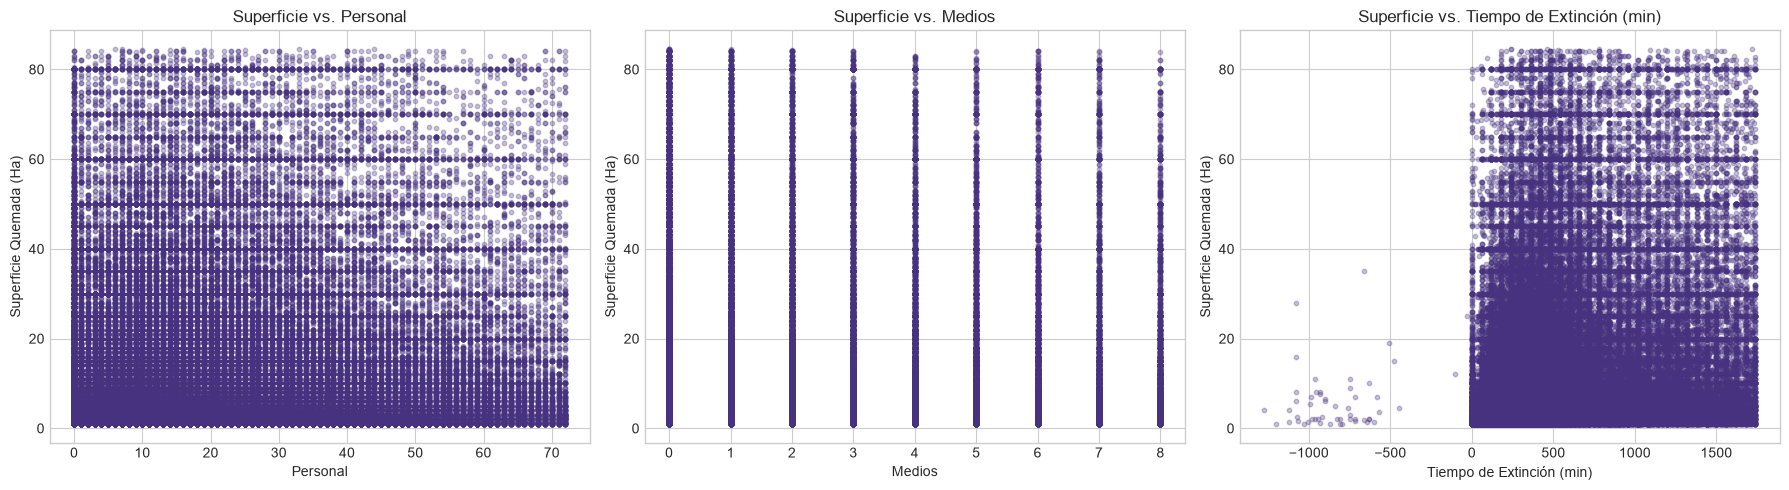

In [135]:
# Scatter plots para ver relaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style("whitegrid")

vars_x = ['personal', 'medios', 'time_ext']
titles_x = ['Personal', 'Medios', 'Tiempo de Extinción (min)']

for i, var_x in enumerate(vars_x):
    # Filtrar valores extremos para mejor visualización
    q95_x = df[var_x].quantile(0.95)
    q95_y = df['superficie'].quantile(0.95)
    data_plot = df.filter((pl.col(var_x) <= q95_x) & (pl.col('superficie') <= q95_y))
    
    axes[i].scatter(data_plot[var_x], data_plot['superficie'], alpha=0.3, s=10)
    axes[i].set_title(f'Superficie vs. {titles_x[i]}')
    axes[i].set_xlabel(titles_x[i])
    axes[i].set_ylabel('Superficie Quemada (Ha)')
    axes[i].grid(True)

plt.tight_layout()
plt.show() # type: ignore

In [136]:
# Correlación (usando transformación logarítmica por sesgo)
log_cols = ['superficie', 'personal', 'medios', 'time_ctrl', 'time_ext']
df_log = df.select([
    pl.col(c).log1p().alias(f'log_{c}') for c in log_cols
])
print("----- Matriz de Correlación (Variables Log-transformadas) -----")
print(df_log.corr())

----- Matriz de Correlación (Variables Log-transformadas) -----
shape: (5, 5)
┌────────────────┬──────────────┬────────────┬───────────────┬──────────────┐
│ log_superficie ┆ log_personal ┆ log_medios ┆ log_time_ctrl ┆ log_time_ext │
│ ---            ┆ ---          ┆ ---        ┆ ---           ┆ ---          │
│ f64            ┆ f64          ┆ f64        ┆ f64           ┆ f64          │
╞════════════════╪══════════════╪════════════╪═══════════════╪══════════════╡
│ 1.0            ┆ 0.315635     ┆ 0.155761   ┆ NaN           ┆ NaN          │
│ 0.315635       ┆ 1.0          ┆ 0.588729   ┆ NaN           ┆ NaN          │
│ 0.155761       ┆ 0.588729     ┆ 1.0        ┆ NaN           ┆ NaN          │
│ NaN            ┆ NaN          ┆ NaN        ┆ NaN           ┆ NaN          │
│ NaN            ┆ NaN          ┆ NaN        ┆ NaN           ┆ NaN          │
└────────────────┴──────────────┴────────────┴───────────────┴──────────────┘


> <br/>
> 💡 Conclusión: Existe una relación moderada a fuerte entre la superficie quemada y el número de personal y medios (a mayor superficie, más recursos). La relación con time_ext también es positiva. Las transformaciones logarítmicas ayudan a visualizar mejor estas relaciones.

> <br/>


##### 4.2. Análisis Geográfico: Incendios por Comunidad

In [137]:
# Diccionarios de mapeo (basados en el estándar INE)

# Comunidades Autónomas (códigos INE)
comunidad_map = {
    1: 'Andalucía',
    2: 'Aragón',
    3: 'Asturias',
    4: 'Baleares',
    5: 'Canarias',
    6: 'Cantabria',
    7: 'Castilla-La Mancha',
    8: 'Castilla y León',
    9: 'Cataluña',
    10: 'Comunidad Valenciana',
    11: 'Extremadura',
    12: 'Galicia',
    13: 'Madrid',
    14: 'Murcia',
    15: 'Navarra',
    16: 'País Vasco',
    17: 'La Rioja'
    # Nota: Ceuta y Melilla podrían tener códigos 18 y 19
}


In [138]:
# Diccionario de provincias (códigos INE 01-52)
provincia_map = {
    1: 'Álava', 2: 'Albacete', 3: 'Alicante', 4: 'Almería', 5: 'Ávila',
    6: 'Badajoz', 7: 'Baleares', 8: 'Barcelona', 9: 'Burgos', 10: 'Cáceres',
    11: 'Cádiz', 12: 'Castellón', 13: 'Ciudad Real', 14: 'Córdoba', 15: 'A Coruña',
    16: 'Cuenca', 17: 'Girona', 18: 'Granada', 19: 'Guadalajara', 20: 'Guipúzcoa',
    21: 'Huelva', 22: 'Huesca', 23: 'Jaén', 24: 'León', 25: 'Lleida',
    26: 'La Rioja', 27: 'Lugo', 28: 'Madrid', 29: 'Málaga', 30: 'Murcia',
    31: 'Navarra', 32: 'Ourense', 33: 'Asturias', 34: 'Palencia', 35: 'Las Palmas',
    36: 'Pontevedra', 37: 'Salamanca', 38: 'Santa Cruz de Tenerife', 39: 'Cantabria',
    40: 'Segovia', 41: 'Sevilla', 42: 'Soria', 43: 'Tarragona', 44: 'Teruel',
    45: 'Toledo', 46: 'Valencia', 47: 'Valladolid', 48: 'Vizcaya', 49: 'Zamora',
    50: 'Zaragoza', 51: 'Ceuta', 52: 'Melilla'
}

In [139]:
df = df.with_columns([
    pl.col("idcomunidad").replace_strict(comunidad_map, default="Desconocido").alias("comunidad_nombre"),
    pl.col("idprovincia").replace_strict(provincia_map, default="Desconocido").alias("provincia_nombre"),
])

In [140]:
# Extraer año
df = df.with_columns(pl.col("fecha").dt.year().alias("anio"))

In [141]:
# --- 4.2.1. ESTADÍSTICAS POR COMUNIDAD ---
community_stats = df.group_by("comunidad_nombre").agg([
    pl.count().alias("num_incendios"),
    pl.sum("superficie").alias("superficie_total"),
    pl.mean("superficie").alias("superficie_promedio"),
    pl.median("superficie").alias("superficie_mediana")
]).sort("num_incendios", descending=True)

print("----- TOP 10 CC.AA. POR NÚMERO DE INCENDIOS -----")
print(community_stats.head(10))

----- TOP 10 CC.AA. POR NÚMERO DE INCENDIOS -----
shape: (10, 5)
┌─────────────────────┬───────────────┬──────────────────┬────────────────────┬────────────────────┐
│ comunidad_nombre    ┆ num_incendios ┆ superficie_total ┆ superficie_promedi ┆ superficie_mediana │
│ ---                 ┆ ---           ┆ ---              ┆ o                  ┆ ---                │
│ str                 ┆ u32           ┆ f64              ┆ ---                ┆ f64                │
│                     ┆               ┆                  ┆ f64                ┆                    │
╞═════════════════════╪═══════════════╪══════════════════╪════════════════════╪════════════════════╡
│ Asturias            ┆ 105767        ┆ 1.9194e6         ┆ 18.147908          ┆ 3.1                │
│ La Rioja            ┆ 46063         ┆ 1.4466e6         ┆ 31.404601          ┆ 5.0                │
│ Canarias            ┆ 33143         ┆ 559509.71        ┆ 16.881686          ┆ 4.0                │
│ Baleares            ┆ 21

C:\Users\MFR\AppData\Local\Temp\ipykernel_10888\3039769165.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_incendios"),


In [142]:
# --- 4.2.2. VISUALIZACIÓN ---
# fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# # Convertir a Pandas solo para Seaborn
# top_communities_pd = community_stats.head(10).to_pandas()